## Домашняя работа №4 по машинному обучению
# 1 часть

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
url = "https://drive.google.com/uc?id=1XkKOS6jbke3JYWTj8V_xS46txe820rZ_"
dataset = pd.read_csv(url)

In [3]:
print(dataset.shape)
dataset.head(5)

(2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
dataset.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [6]:
dataset.isnull().sum()   
dataset.duplicated().sum()

np.int64(0)

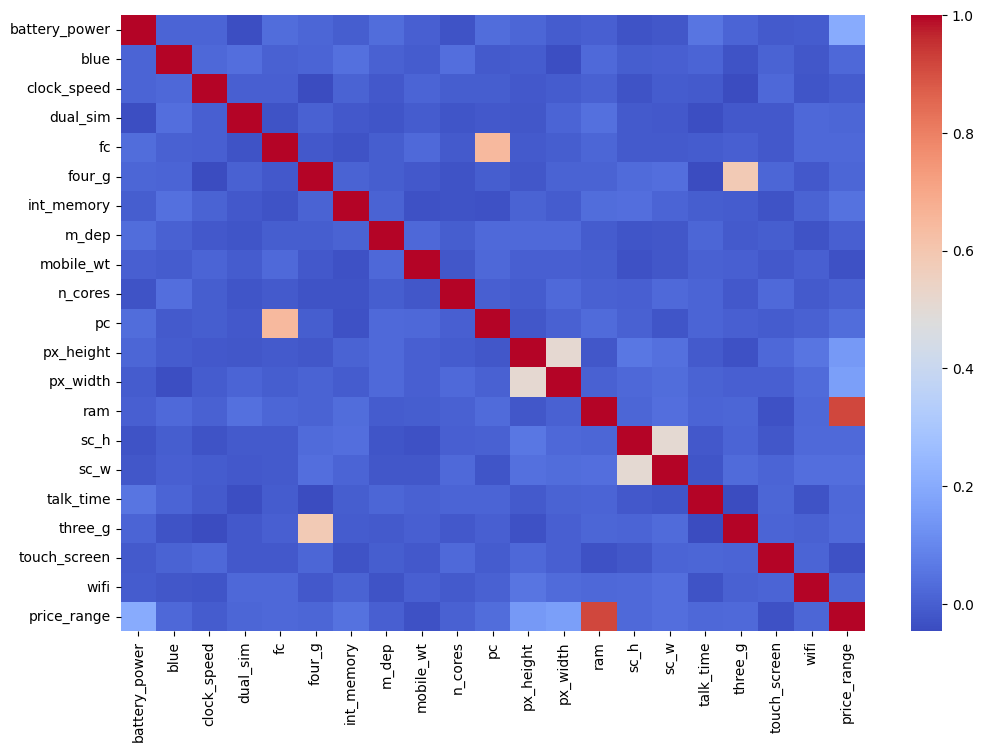

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.corr(), cmap='coolwarm')
plt.show()

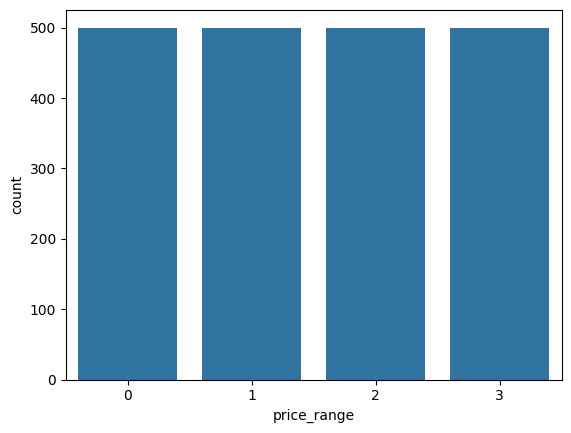

In [ ]:
dataset['price_range'].value_counts()
sns.countplot(x='price_range', data=dataset)
plt.show()

По проведенному выше анализу мы видим, что в датасете нет пропусков, дубликатов, распределение примерно равномерное, и впринципе данные не требуют обработки.

In [9]:
dataset['screen_area'] = dataset['sc_h'] * dataset['sc_w']
dataset['pixel_area'] = dataset['px_height'] * dataset['px_width']

In [10]:
from sklearn.model_selection import train_test_split

X = dataset.drop('price_range', axis=1)
y = dataset['price_range']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

В работе буду использовать accuracy -- для общей оценки качества и F1-macro -- для учета качества по всем классам

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.9625
F1: 0.962458950972207


In [13]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.mean(np.abs(logreg.coef_), axis=0)
}).sort_values(by='importance', ascending=False)

importance

,feature,importance
13,ram,7.163569
0,battery_power,1.782649
12,px_width,0.924928
11,px_height,0.658653
21,pixel_area,0.455239
8,mobile_wt,0.305662
20,screen_area,0.163607
6,int_memory,0.122846
19,wifi,0.120185
15,sc_w,0.103419


Базовая модель логистической регрессии показала высокое качество: Accuracy = 0.9625 и F1-macro = 0.9624... Это свидетельствует о том, что модель хорошо справляется с задачей классификации и одинаково точно предсказывает все классы. 

По признакам на первом месте с большим отрывом ram (7.16), потом battery_power = 1.782649 и px_width = 0.924928. В принципе логично, что оперативная память является ключевым фактором. Батарея и пиксели экрана тоже сильно влияют. 

Признаки дополнительные, которые не так важны оказались последние в списке. Они есть уже почти у всех мобильных устройств, поэтому не представляют из себя важных факторов. Это blu - bluetooth, wifi, front camera, 3G, talk_time...

In [14]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5,
    scoring='f1_macro'
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

{'C': 10}


Это значит слабая регуляризация, модель больше подстраивается под данные и увеличивает коэффициенты признаков, улучшая качество

In [15]:
best_logreg = LogisticRegression(C=10, max_iter=1000)
best_logreg.fit(X_train_scaled, y_train)

y_pred_best = best_logreg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best, average='macro'))

Accuracy: 0.975
F1: 0.974998105917115


In [16]:
importance_tuned = pd.DataFrame({
    'feature': X.columns,
    'importance': np.mean(np.abs(best_logreg.coef_), axis=0)
}).sort_values(by='importance', ascending=False)

importance_tuned

,feature,importance
13,ram,15.719357
0,battery_power,3.937882
12,px_width,2.240577
11,px_height,2.016498
8,mobile_wt,0.658229
21,pixel_area,0.500890
6,int_memory,0.330507
19,wifi,0.258974
20,screen_area,0.249256
9,n_cores,0.153339


После подбора гиперпараметров качество модели, конечно не радикально, но улучшилось. Accuracy выросла с 0.9625 до 0.975, F1 также увеличилась до 0.975. Получается, уменьшение регуляризации позволило модели лучше подстроиться под данные.

По признакам, их порядок по важности не изменился, но признаки некоторых увеличились. Например, важность ram выросла почти в 2 раза. Признаки у последних в списке не изменились, значит, они правда не важны. 

In [17]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("F1:", f1_score(y_test, y_pred_lgbm, average='macro'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000238 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1739
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 22
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Accuracy: 0.935
F1: 0.935139147459426


Модель тоже хорошо работает, но качество модели чуть упало: Accuracy: 0.935
F1: 0.935139147459426. Зависимость между признаками и целевой переменной в датасете близка к линейной, и логистическая регрессия справляется с задачей лучше. Вообщем, с этим датасетом лучше работать на простых моделях.
 

In [18]:
params = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50]
}

grid_lgbm = GridSearchCV(
    LGBMClassifier(),
    params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lgbm.fit(X_train, y_train)

print(grid_lgbm.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1739
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 22
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

Гиперпараметры бустинга: max_depth -- ограничение глубины дерева (прямое ограничение, помогает против переобучения), subsample -- доля случайно выбранных строк для каждого дерева (стохастический бустинг), colsample_bytree -- доля случайно выбранных признаков для каждого дерева.n_estimators -- количество деревьев в ансамбле. Чем больше деревьев, тем сложнее модель, но возрастает риск переобучения, learning_rate -- шаг обучения (скорость адаптации). Маленький шаг требует больше деревьев, но часто даёт лучшее обобщение, num_leaves -- максимальное количество листьев в одном дереве. Аналог глубины: чем больше листьев, тем более сложные зависимости модель может выучить.

В работе выполнен подбор гиперпараметров методом GridSearchCV с 3-кратной кросс-валидацией по метрике F1-macro. Лучшие параметры: {'learning_rate': 0.1, 'n_estimators': 300, 'num_leaves': 50}. 

In [21]:
y_pred_lgbm_best = lgbm_best.predict(X_test)
print("Accuracy (tuned):", accuracy_score(y_test, y_pred_lgbm_best))
print("F1 (tuned):", f1_score(y_test, y_pred_lgbm_best, average='macro'))

Accuracy (tuned): 0.925
F1 (tuned): 0.9251736858606558


In [19]:
lgbm_best = grid_lgbm.best_estimator_

importance_lgbm = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_best.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_lgbm

,feature,importance
13,ram,7027
0,battery_power,4828
21,pixel_area,3152
12,px_width,2961
11,px_height,1890
8,mobile_wt,1800
6,int_memory,1279
20,screen_area,992
16,talk_time,935
2,clock_speed,847


Мы видим, что качество модели улучшилось, но все равно не такое, как было у первой и второй моделей (LogisticRegression (базовая) и LogisticRegression (C=10))
Лидирует по признакам снова ram, batery_power, а на третьем месте уже не px_width, а pixel_area. Бустинг лучше выявляет нелинейное взаимодействие между px_height и px_width. Линейная модель вынуждена оценивать их вклад независимо, а их произведение вносит дополнительную информацию об общей площади экрана. Признаки, ставшие стандартными (bluetooth, 3G, 4G, Wi-Fi), практически не влияют на цену снова. int_memory и mobile_wt в LGBM находятся выше (6‑е и 5‑е места), чем в LR (7‑е и 5‑е соответственно) различия не кардинальны, но показывают, что бустинг чуть чувствительнее к весу и встроенной памяти.

Скорее всего, это произошло из-за того логистическая регрессия не видит, что высота и ширина вместе важны, поэтому для неё площадь экрана не в почёте. А бустинг сам догадывается об этом, поэтому площадь для него оказывается полезной. В остальном, все схоже.

In [20]:
results = X_test.copy()
results['true'] = y_test
results['pred'] = y_pred_lgbm

good = results[results['true'] == results['pred']]
bad = results[results['true'] != results['pred']]

bad.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,screen_area,pixel_area,true,pred
387,560,0,0.5,0,14,0,23,1.0,146,8,...,17,16,18,0,1,1,272,677468,1,2
1303,888,0,2.6,1,2,1,33,0.4,198,2,...,12,1,20,1,0,0,12,550341,3,2
1946,590,1,1.2,1,0,0,32,0.4,141,6,...,10,0,6,0,1,0,0,115543,0,1
109,1775,1,1.5,0,3,0,41,0.1,163,1,...,19,13,14,1,1,1,247,3052077,3,2
475,1122,0,1.2,0,9,0,2,0.6,120,4,...,11,2,13,1,1,1,22,261490,2,3


Ошибки происходят на пограничных телефонах, где сочетание характеристик не укладывается в чёткий шаблон

In [22]:
good.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,screen_area,pixel_area,true,pred
501,1773,1,2.5,0,16,1,32,0.6,170,6,...,17,6,13,1,0,1,102,1788480,3,3
1924,1982,1,1.6,0,2,1,12,0.2,80,5,...,13,3,14,1,1,1,39,170191,1,1
1710,548,0,1.0,1,0,1,56,0.4,146,4,...,17,14,8,1,1,1,238,1088649,0,0
547,1117,1,0.6,1,0,0,31,0.2,146,2,...,8,7,14,0,1,1,56,2046766,2,2
496,1554,1,0.5,1,11,0,5,1.0,124,3,...,7,4,18,0,0,0,28,623705,3,3


Модель уверенно классифицирует телефоны с классическим сочетанием признаков (например, высокий RAM + дорогой, низкий RAM + дешёвый)

# Итоги

In [24]:
results_summary = pd.DataFrame({
    'Модель': [
        'LogisticRegression (базовая)',
        'LogisticRegression (C=10)',
        'LightGBM (базовая)',
        'LightGBM (tuned)'
    ],
    'Accuracy': [0.9625, 0.975, 0.935, 0.925],
    'F1-macro': [0.9625, 0.975, 0.935, 0.925]
})

print(results_summary.to_string(index=False))

                      Модель  Accuracy  F1-macro
LogisticRegression (базовая)    0.9625    0.9625
   LogisticRegression (C=10)    0.9750    0.9750
          LightGBM (базовая)    0.9350    0.9350
            LightGBM (tuned)    0.9250    0.9250


Лучший результат достигнут логистической регрессией с C=10 (97.5%). Градиентный бустинг в данном случае избыточен и даже немного проигрывает базовой версии после настройки. Для такого набора данных предпочтительнее использовать линейные модели из‑за их простоты, интерпретируемости и более высокого качества.

## 2 часть 

In [18]:
url = "https://drive.google.com/uc?export=download&id=1NirC6JEBFtOeHFpC0WCsjkprbeLp9pyw"

df = pd.read_csv(url)
print(df.shape)
df.head(5)

(62630, 16)


,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


In [19]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      62630 non-null  int64  
 1   UTC             62630 non-null  int64  
 2   Temperature[C]  62630 non-null  float64
 3   Humidity[%]     62630 non-null  float64
 4   TVOC[ppb]       62630 non-null  int64  
 5   eCO2[ppm]       62630 non-null  int64  
 6   Raw H2          62630 non-null  int64  
 7   Raw Ethanol     62630 non-null  int64  
 8   Pressure[hPa]   62630 non-null  float64
 9   PM1.0           62630 non-null  float64
 10  PM2.5           62630 non-null  float64
 11  NC0.5           62630 non-null  float64
 12  NC1.0           62630 non-null  float64
 13  NC2.5           62630 non-null  float64
 14  CNT             62630 non-null  int64  
 15  Fire Alarm      62630 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 7.6 MB


,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,62630.000000,6.263000e+04,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,31314.500000,1.654792e+09,15.970424,48.539499,1942.057528,670.021044,12942.453936,19754.257912,938.627649,100.594309,184.467770,491.463608,203.586487,80.049042,10511.386157,0.714626
std,18079.868017,1.100025e+05,14.359576,8.865367,7811.589055,1905.885439,272.464305,609.513156,1.331344,922.524245,1976.305615,4265.661251,2214.738556,1083.383189,7597.870997,0.451596
min,0.000000,1.654712e+09,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15657.250000,1.654743e+09,10.994250,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000,3625.250000,0.000000
50%,31314.500000,1.654762e+09,20.130000,50.150000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.943000,0.044000,9336.000000,1.000000
75%,46971.750000,1.654778e+09,25.409500,53.240000,1189.000000,438.000000,13109.000000,20078.000000,939.418000,2.090000,2.180000,14.420000,2.249000,0.051000,17164.750000,1.000000
max,62629.000000,1.655130e+09,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000,24993.000000,1.000000


In [20]:
df.isnull().sum()   
df.duplicated().sum()

np.int64(0)

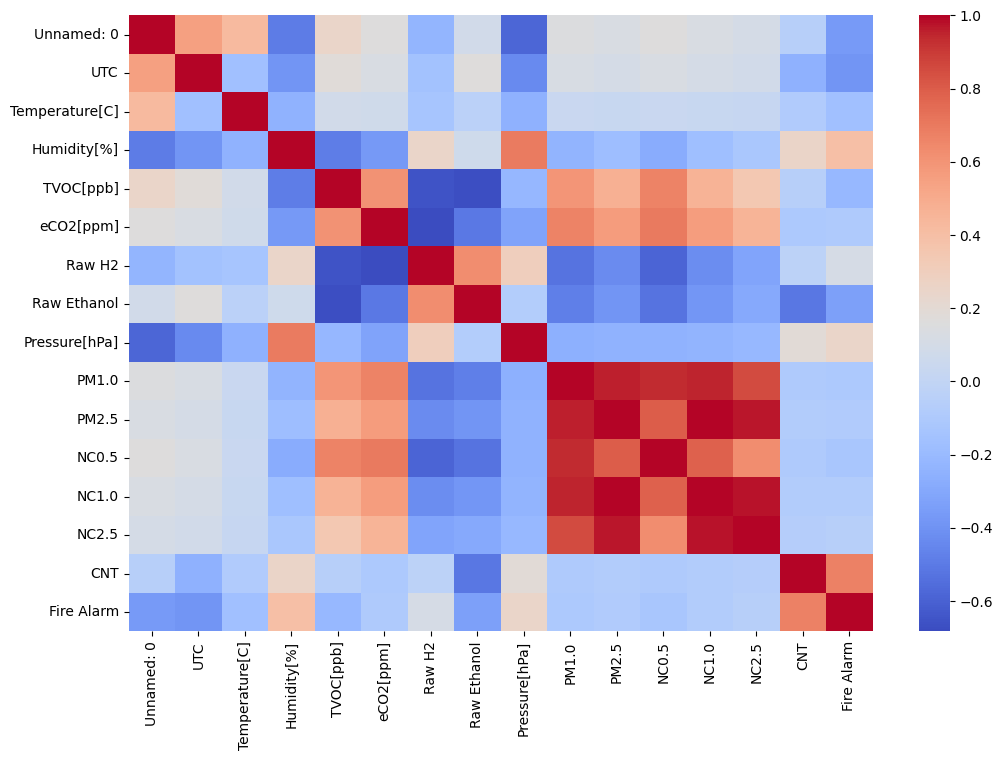

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

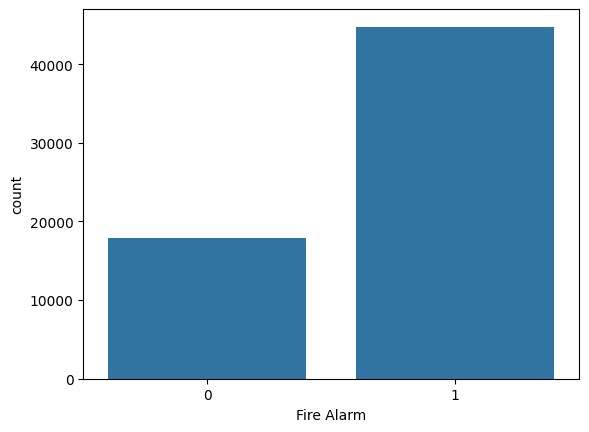

In [22]:
df['Fire Alarm'].value_counts()
sns.countplot(x='Fire Alarm', data=df)
plt.show()

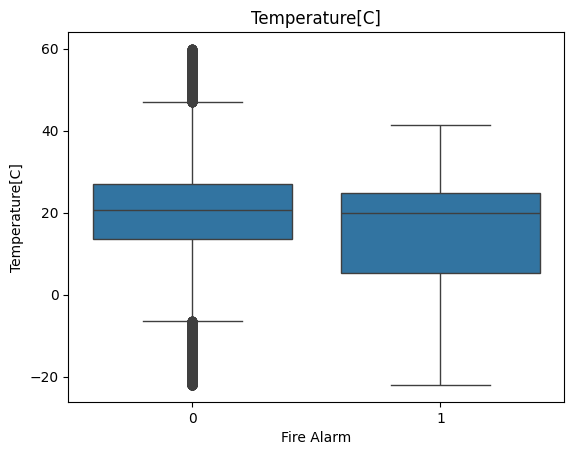

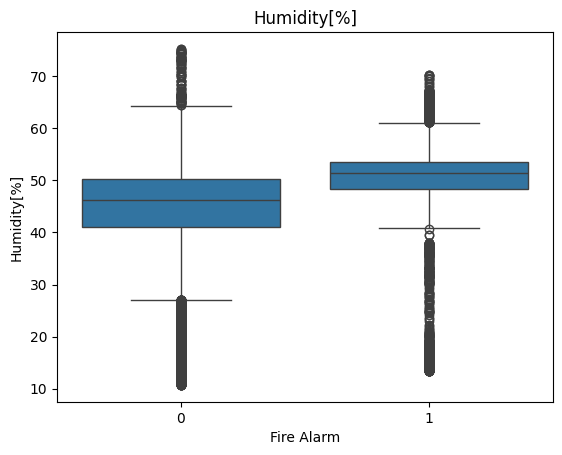

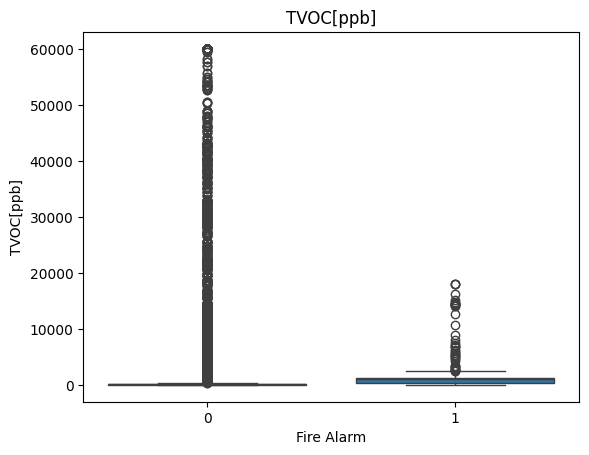

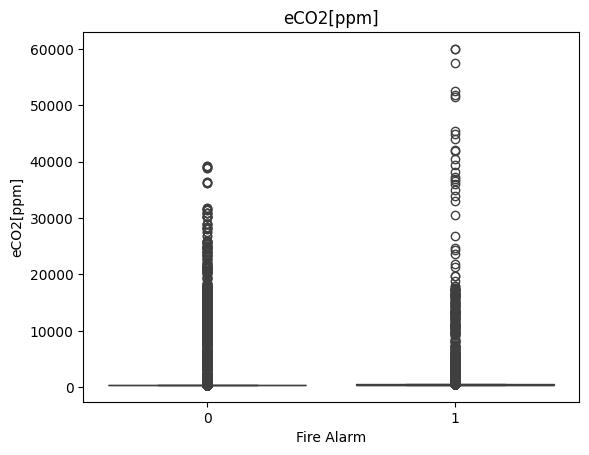

In [23]:
features = ['Temperature[C]', 'Humidity[%]', 'TVOC[ppb]', 'eCO2[ppm]']

for col in features:
    sns.boxplot(x='Fire Alarm', y=col, data=df)
    plt.title(col)
    plt.show()

Пропусков и дубликатов в данных нет

Удалим Unnamed: 0 (это просто лишний индекс из CSV), еще UTC (не числовой признак для hist) и CNT т.к. он ничего не значит для модели

In [24]:
df = df.drop(columns=["Unnamed: 0", "CNT", "UTC"], errors="ignore")

Cоздадим новые признаки, чтобы усилить сигнал частиц и добавить агрегированные газовые характеристики:
PM_sum = PM1.0 + PM2.5
NC_sum = NC0.5 + NC1.0 + NC2.5
Gas_ratio = Raw Ethanol / (Raw H2 + 1)


In [ ]:
df['PM_sum'] = df['PM1.0'] + df['PM2.5']
df['NC_sum'] = df['NC0.5'] + df['NC1.0'] + df['NC2.5']
df['Gas_ratio'] = df['Raw Ethanol'] / (df['Raw H2'] + 1)

In [41]:
from sklearn.model_selection import train_test_split
df.columns = df.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

X = df.drop('Fire_Alarm', axis=1)   
y = df['Fire_Alarm']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Для задачи обнаружения пожара (несбалансированные классы) основная метрика -- F1-мера, так как она учитывает и полноту, и точность. ROC-AUC показывает способность модели разделять классы. Recall важен, чтобы не пропустить реальный пожар.

In [42]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [44]:
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:,1]

print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

F1: 0.9278136279120639
ROC-AUC: 0.9657009999273435
              precision    recall  f1-score   support

           0       0.85      0.76      0.80      3575
           1       0.91      0.95      0.93      8951

    accuracy                           0.89     12526
   macro avg       0.88      0.85      0.87     12526
weighted avg       0.89      0.89      0.89     12526



In [45]:
thresholds = np.arange(0.1, 0.9, 0.01)

best_t, best_f1 = 0, 0

for t in thresholds:
    preds = (y_proba > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.21999999999999995
Best F1: 0.9332358928851072


In [46]:
lr_importance = pd.DataFrame({
    "feature": X_train.columns,
    "coef": pipe.named_steps['model'].coef_[0]
}).sort_values(by="coef", ascending=False)

lr_importance

,feature,coef
3,eCO2_ppm_,5.882280
5,Raw_Ethanol,4.685353
1,Humidity_,1.293490
11,NC2_5,-0.032007
10,NC1_0,-0.115559
8,PM2_5,-0.123074
12,PM_sum,-0.155963
7,PM1_0,-0.222060
13,NC_sum,-0.232383
9,NC0_5,-0.316420


Самые важные признаки: eCO2_ppm (5.88), Raw_Ethanol (4.68) и Humidity (1.29). Самый последний в списке -- TVOC_ppb (сильный отрицательный коэффициент). То есть снижают вероятность поражара температура, давление и т.д. 

Вывод, логистическая регрессия хорошо выявляет линейные зависимости между газовыми сенсорами и пожаром.

In [47]:
from sklearn.model_selection import GridSearchCV

params = {
    'model__C': [0.01, 0.1, 1, 10]
}

search = GridSearchCV(pipe, params, scoring='f1', cv=3)
search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'model__C': 0.1}
0.9292188200855244


In [48]:
best_lr = search.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:,1]

print("F1:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

F1: 0.9285403050108932
ROC-AUC: 0.9583895849430426


Качество слегка улучшилось по F1, ROC-AUC немного снизился (модель стала более регуляризованной), а веса признаков стали более устойчивыми

Регуляризация стабилизировала модель, уменьшив переобучение.

In [49]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 35806, number of negative: 14298
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001963 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 50104, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.714634 -> initscore=0.917996
[LightGBM] [Info] Start training from score 0.917996


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [50]:
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:,1]

print("F1:", f1_score(y_test, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgbm))

F1: 1.0
ROC-AUC: 1.0


In [51]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'num_leaves': [31, 50],
    'max_depth': [-1, 10],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300]
}

search = RandomizedSearchCV(
    lgbm,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_lgbm = search.best_estimator_

print(search.best_params_)

[LightGBM] [Info] Number of positive: 35806, number of negative: 14298
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 50104, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.714634 -> initscore=0.917996
[LightGBM] [Info] Start training from score 0.917996
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [52]:
y_proba_lgbm = best_lgbm.predict_proba(X_test)[:,1]

best_t_lgbm, best_f1_lgbm = 0, 0

for t in thresholds:
    preds = (y_proba_lgbm > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1_lgbm:
        best_f1_lgbm = f1
        best_t_lgbm = t

print(best_t_lgbm, best_f1_lgbm)

0.1 1.0


LightGBM идеально разделил классы. 

In [53]:
lgbm_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_lgbm.feature_importances_
}).sort_values(by="importance", ascending=False)

lgbm_importance

,feature,importance
2,TVOC_ppb_,1065
6,Pressure_hPa_,993
5,Raw_Ethanol,792
7,PM1_0,776
0,Temperature_C_,726
1,Humidity_,605
4,Raw_H2,501
14,Gas_ratio,468
3,eCO2_ppm_,389
11,NC2_5,145


Здесь по признакам самыми важными оказались TVOC_ppb, Pressure и Raw Ethanol. Различия с Logistic Regression есть и скорее всего связанны с тем, что бустинг ловит взаимодействия признаков, а Logistic Regression работает только с линейной зависимостью.

In [54]:
results = X_test.copy()
results["y_true"] = y_test
results["y_pred"] = y_pred_lgbm
results["proba"] = y_proba_lgbm

In [55]:
results[(results.y_true == results.y_pred) & (results.proba > 0.9)].head()

,Temperature_C_,Humidity_,TVOC_ppb_,eCO2_ppm_,Raw_H2,Raw_Ethanol,Pressure_hPa_,PM1_0,PM2_5,NC0_5,NC1_0,NC2_5,PM_sum,NC_sum,Gas_ratio,y_true,y_pred,proba
37741,27.080,46.95,1042,541,12837,19471,938.972,2.07,2.15,14.27,2.225,0.050,4.22,16.545,1.516669,1,1,1.0
44970,24.440,53.92,1153,402,12930,19449,938.756,1.55,1.61,10.68,1.666,0.038,3.16,12.384,1.504060,1,1,1.0
15708,12.006,52.99,1220,436,12870,19432,938.808,1.93,2.00,13.25,2.067,0.047,3.93,15.364,1.509751,1,1,1.0
17356,15.564,48.00,1170,404,12897,19433,938.758,1.77,1.84,12.19,1.900,0.043,3.61,14.133,1.506668,1,1,1.0
24815,10.994,50.86,1356,426,12982,19383,938.853,2.24,2.33,15.42,2.405,0.054,4.57,17.879,1.492952,1,1,1.0


Модель уверенно определяет пожар при резком росте газов и повышенной концентрации частиц

In [57]:
results[(results.y_true != results.y_pred)].head()

,Temperature_C_,Humidity_,TVOC_ppb_,eCO2_ppm_,Raw_H2,Raw_Ethanol,Pressure_hPa_,PM1_0,PM2_5,NC0_5,NC1_0,NC2_5,PM_sum,NC_sum,Gas_ratio,y_true,y_pred,proba


LightGBM показал идеальное качество классификации (F1 = 1.0, ROC-AUC = 1.0, error rate = 0.0). Это означает, что модель не допустила ни одной ошибки на тестовой выборке.

In [58]:
summary = pd.DataFrame({
    "Model": ["LogReg", "LogReg tuned", "LightGBM"],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lgbm)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_lgbm)
    ]
})

summary

,Model,F1,ROC-AUC
0,LogReg,0.927814,0.965701
1,LogReg tuned,0.928540,0.958390
2,LightGBM,1.000000,1.000000


Logistic Regression показала стабильное базовое качество (F1 = 0.93, ROC-AUC = 0.97), что говорит о наличии выраженных линейных зависимостей в данных. После подбора гиперпараметра C наблюдается небольшое улучшение F1, однако ROC-AUC немного снижается, что указывает на компромисс между обобщающей способностью и чувствительностью модели. LightGBM демонстрирует идеальные метрики (F1 = 1.0, ROC-AUC = 1.0), что свидетельствует о практически полной разделимости классов в признаковом пространстве. В целом, бустинг лучше всего улавливает сложные нелинейные зависимости и обеспечивает максимальное качество классификации.